In [1]:
import os
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image

# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [2]:
# --- CELL 2: THE SHARED CLIPBOARD (STATE) ---
class SentinelState(TypedDict):
    user_query: str      # e.g., "Give me a price alert" or "Tell me the news"
    intent: str          # The decision made by the Router
    response: str        # The final answer

In [3]:
# --- CELL 3: THE WORKERS (NODES) ---

def router_node(state: SentinelState):
    print("📋 Router: Analyzing user intent...")
    query = state['user_query'].lower()

    # Simple logic to simulate "Intelligent Routing"
    if "price" in query or "stock" in query:
        return {"intent": "market_data"}
    else:
        return {"intent": "news_update"}

def market_specialist_node(state: SentinelState):
    print("📈 Market Specialist: Accessing real-time tickers...")
    return {"response": "The current price is $180.50 (Up 1.2%)."}

def news_specialist_node(state: SentinelState):
    print("📰 News Specialist: Accessing global headlines...")
    return {"response": "Breaking: CEO announces new sustainability initiative."}

In [4]:
# --- CELL 4: THE ROUTING LOGIC ---
# This function tells LangGraph which path to take based on the state
def route_decision(state: SentinelState) -> Literal["market_path", "news_path"]:
    if state["intent"] == "market_data":
        return "market_path"
    return "news_path"

In [5]:
# --- CELL 5: THE FLOOR PLAN (GRAPH) ---
builder = StateGraph(SentinelState)

# 1. Add Nodes
builder.add_node("router", router_node)
builder.add_node("market_pro", market_specialist_node)
builder.add_node("news_pro", news_specialist_node)

# 2. Define Flow
builder.add_edge(START, "router")

# 3. Add Conditional Edges (The Fork in the Road)
builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "market_path": "market_pro",
        "news_path": "news_pro"
    }
)

builder.add_edge("market_pro", END)
builder.add_edge("news_pro", END)

sentinel_router = builder.compile()

In [6]:
# --- CELL 6: RUNNING THE LINE ---
# Test 1: Market Query
print("--- TEST 1: Market Query ---")
res1 = sentinel_router.invoke({"user_query": "What is the price?"})
print(f"Result: {res1['response']}\n")

# Test 2: News Query
print("--- TEST 2: General Query ---")
res2 = sentinel_router.invoke({"user_query": "Anything happening today?"})
print(f"Result: {res2['response']}")

--- TEST 1: Market Query ---
📋 Router: Analyzing user intent...
📈 Market Specialist: Accessing real-time tickers...
Result: The current price is $180.50 (Up 1.2%).

--- TEST 2: General Query ---
📋 Router: Analyzing user intent...
📰 News Specialist: Accessing global headlines...
Result: Breaking: CEO announces new sustainability initiative.


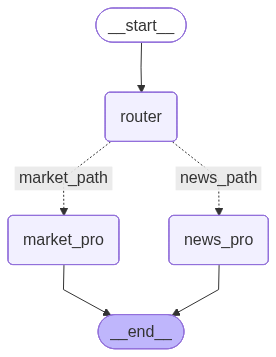

In [8]:
png_bytes = sentinel_router.get_graph().draw_mermaid_png()

# Save to file
with open("sentinel_router.png", "wb") as f:
    f.write(png_bytes)

# Display in notebook
display(Image(data=png_bytes))